# Irrigation Prediction 

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
RANDOM_STATE = 42

In [4]:
df = pd.read_csv('irrigation_prediction.csv')
print('shape:', df.shape)
print(df.head(2).to_string(index=False))

target = 'Irrigation_Need'
assert target in df.columns

print('Target distribution:')
print(df[target].value_counts())

shape: (10000, 20)
Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage Season Irrigation_Type Water_Source  Field_Area_hectare Mulching_Used  Previous_Irrigation_mm  Region Irrigation_Need
     Clay     6.14          36.48            0.42                     2.17           21.9     31.19      1167.70            4.01            1.97     Wheat        Vegetative   Rabi         Rainfed    Reservoir                4.73           Yes                    1.98   South             Low
     Silt     6.41          50.56            0.38                     0.23           36.5     26.01       831.28           10.72           16.82     Maize         Flowering   Zaid           Canal  Groundwater               12.22           Yes                   33.56 Central          Medium
Target distribution:
Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64


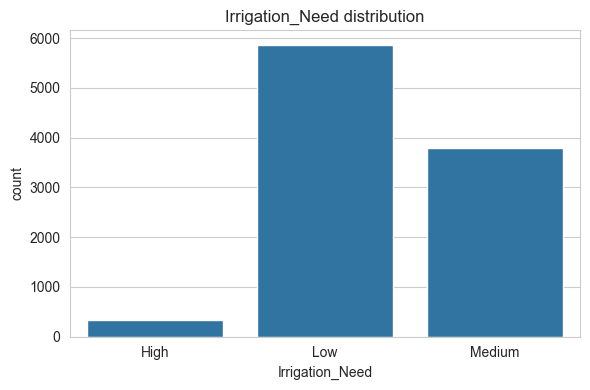

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target, order=sorted(df[target].unique()))
plt.title('Irrigation_Need distribution')
plt.tight_layout()
plt.show()

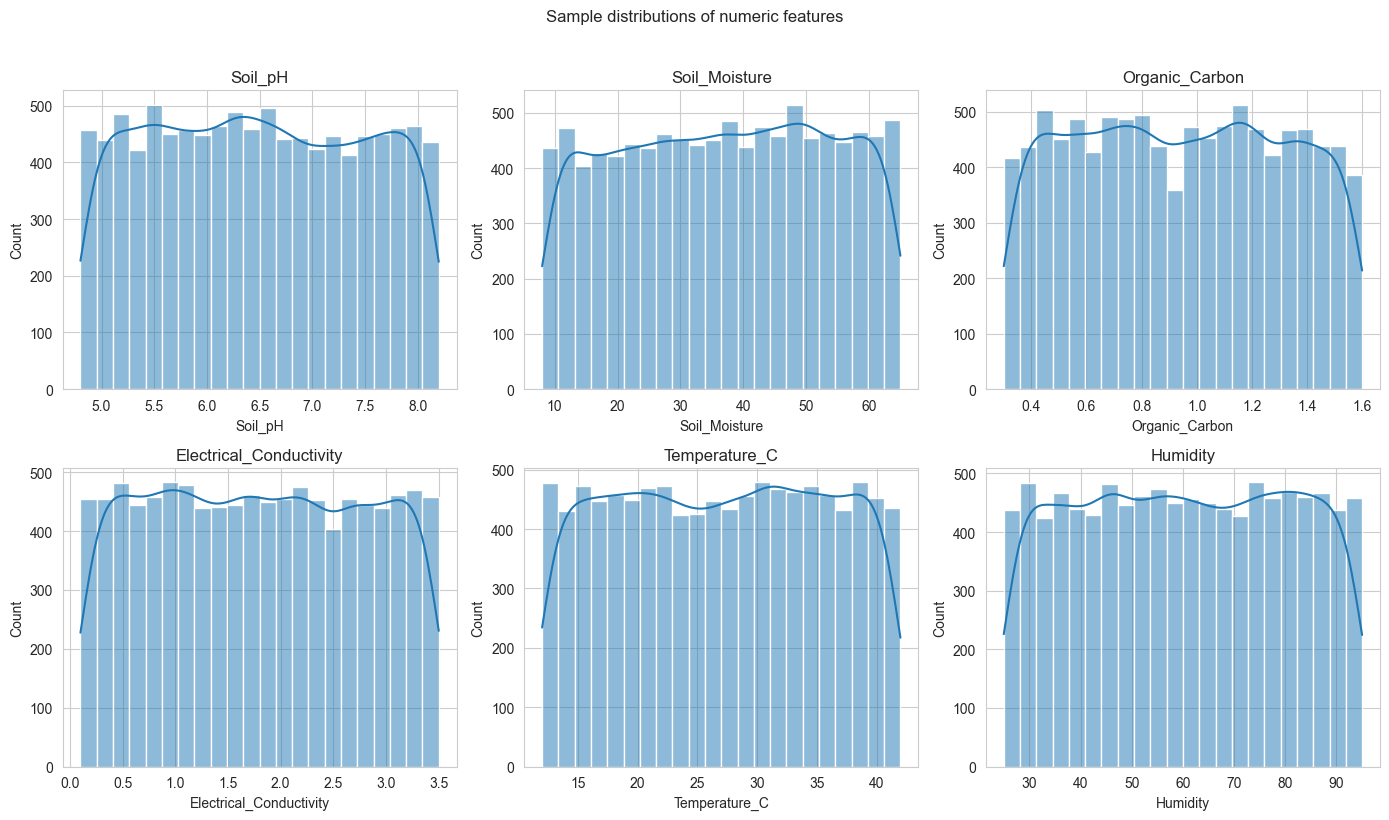

In [6]:

numeric_cols = [c for c in df.columns if df[c].dtype != 'object' and c != target]
plot_cols = numeric_cols[:6]  # first 6 numeric features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Sample distributions of numeric features', y=1.02)
plt.tight_layout()
plt.show()

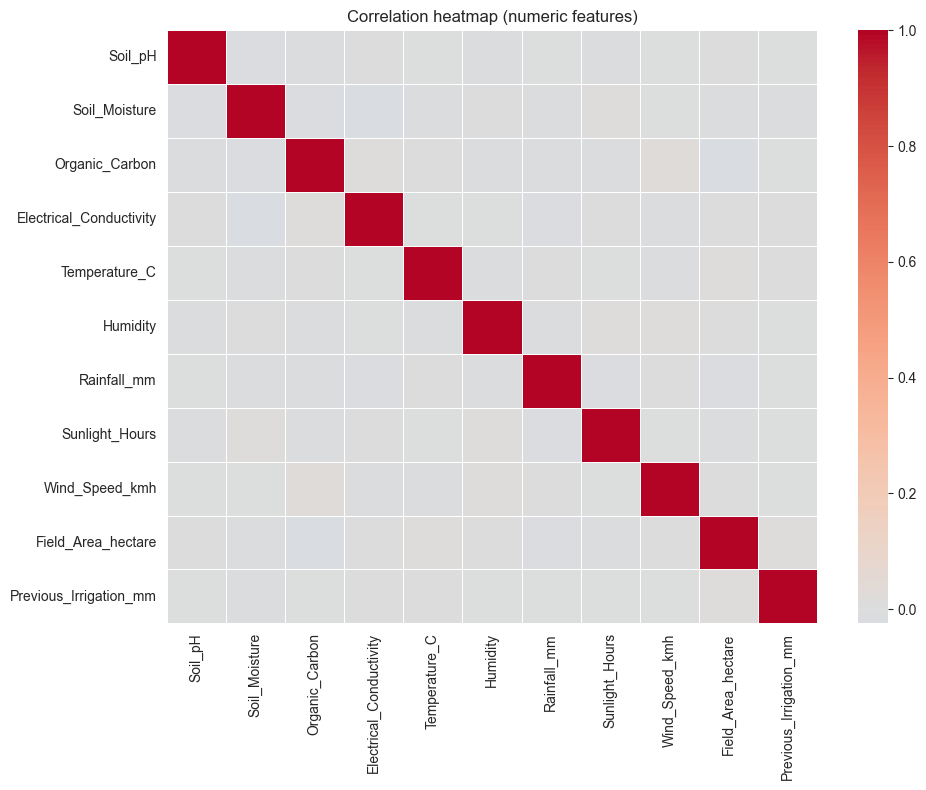

In [7]:

corr_df = df[numeric_cols].copy()
corr = corr_df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.show()

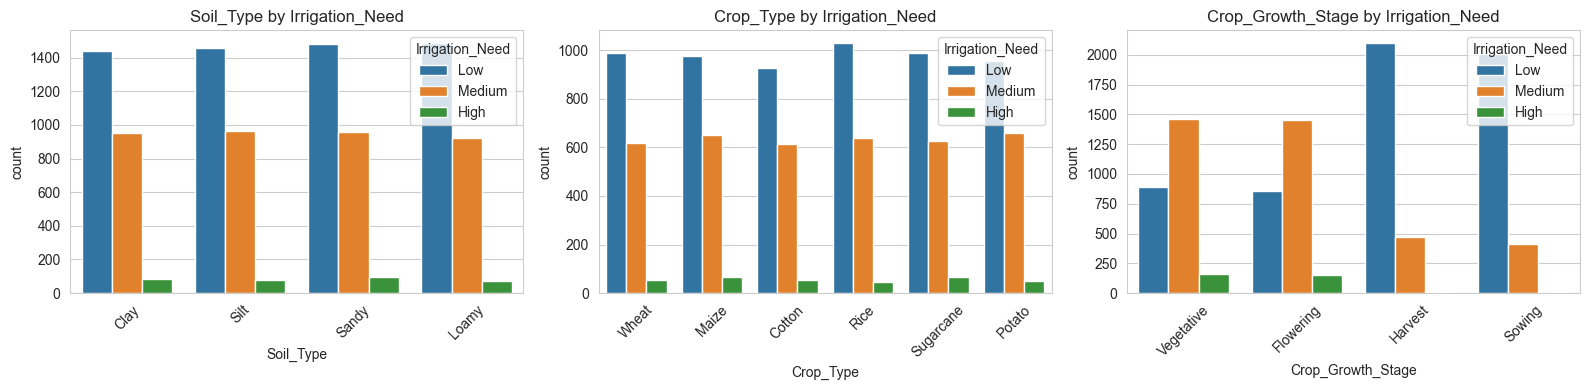

In [8]:

categorical_cols = [c for c in df.columns if df[c].dtype == 'object' and c != target]
top_cats = categorical_cols[:3]
fig, axes = plt.subplots(1, len(top_cats), figsize=(16, 4))
if len(top_cats) == 1:
    axes = [axes]
for ax, col in zip(axes, top_cats):
    sns.countplot(data=df, x=col, hue=target, ax=ax)
    ax.set_title(f'{col} by {target}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

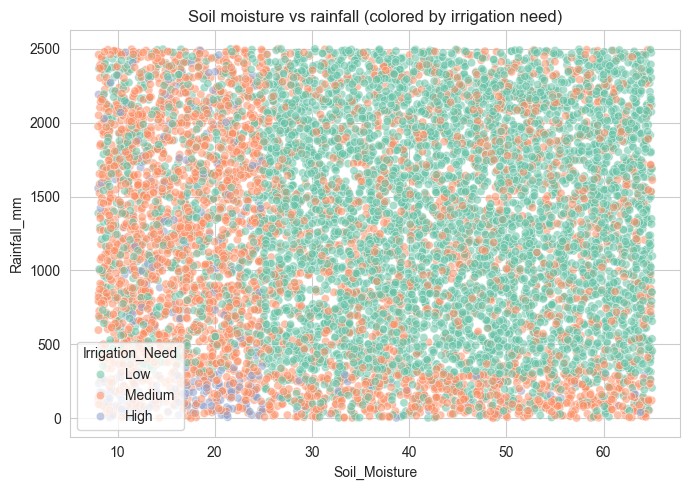

In [9]:

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='Soil_Moisture',
    y='Rainfall_mm',
    hue=target,
    alpha=0.55,
    palette='Set2'
)
plt.title('Soil moisture vs rainfall (colored by irrigation need)')
plt.tight_layout()
plt.show()

In [10]:

X = df.drop(columns=[target])
y = df[target]

categorical_cols = [c for c in X.columns if X[c].dtype == 'object']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('train:', X_train.shape, 'test:', X_test.shape)

train: (8000, 19) test: (2000, 19)


In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

clf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

model = Pipeline(steps=[('preprocess', preprocess), ('clf', clf)])
model.fit(X_train, y_train)
print('training complete')

training complete


In [12]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9735

Confusion matrix:
[[  25    0   42]
 [   0 1173    0]
 [   0   11  749]]

Classification report:
              precision    recall  f1-score   support

        High       1.00      0.37      0.54        67
         Low       0.99      1.00      1.00      1173
      Medium       0.95      0.99      0.97       760

    accuracy                           0.97      2000
   macro avg       0.98      0.79      0.83      2000
weighted avg       0.97      0.97      0.97      2000



In [13]:
# Example prediction using the first test row
sample = X_test.iloc[[0]].copy()
true_label = y_test.iloc[0]
pred_label = model.predict(sample)[0]

print('True:', true_label)
print('Pred:', pred_label)
print('Sample features (single row):')
print(sample.to_string(index=False))

True: Medium
Pred: Medium
Sample features (single row):
Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage Season Irrigation_Type Water_Source  Field_Area_hectare Mulching_Used  Previous_Irrigation_mm Region
     Silt     6.56           26.1            0.35                     3.38          18.11     43.18       1416.9            9.44           12.15 Sugarcane         Flowering   Zaid       Sprinkler        River                7.25            No                   51.55  North


In [14]:
# Save model artifact
import joblib
joblib.dump(model, 'irrigation_model.joblib')
print('Saved: irrigation_model.joblib')

Saved: irrigation_model.joblib


In [15]:
# Recommendation mapping + final prediction print

def recommend_from_label(label: str) -> str:
    advice = {
        'Low': 'Irrigation need is LOW. Consider minimal irrigation and monitor soil moisture before next irrigation.',
        'Medium': 'Irrigation need is MEDIUM. Use scheduled irrigation to maintain optimal soil moisture.',
        'High': 'Irrigation need is HIGH. Consider higher irrigation frequency/amount and verify water availability.',
    }
    return advice.get(label, 'Irrigation need is unknown. Use local agronomy guidance.')

def predict_one(model, input_row: pd.DataFrame):
    pred_class = model.predict(input_row)[0]
    return pred_class, recommend_from_label(pred_class)

pred_class, recommendation = predict_one(model, sample)
print('\n=== Final Prediction ===')
print('Irrigation_Need:', pred_class)
print('Recommendation:')
print(recommendation)


=== Final Prediction ===
Irrigation_Need: Medium
Recommendation:
Irrigation need is MEDIUM. Use scheduled irrigation to maintain optimal soil moisture.
